<html> <h1 style="font-style:bold; color:blue;"> Neural Computing and Deep Learning </h1> </html>

<html> <h1 style="font-style:italic; color:blue;"> Week-5 </h1> </html>

<html> <h2 style="font-style:italic; color:blue;"> Convolution Neural Networks </h2> </html>

<html> <h2 style="font-style:italic; color:blue;"> Task 1 : </h2> </html>

#### Develop and evaluate an image classifier using Convolution Neural Network.

### The Data = CIFAR 10, Multiple Classes datset.

CIFAR-10 is a dataset of 50,000 32x32 color training images, labeled over 10 categories, and 10,000 test images.

ttps://www.cs.toronto.edu/~kriz/cifar.html

Example of using Keras for CNNs. Use a famous data set, the CIFAR-10 dataset which consists of 10 different image types.

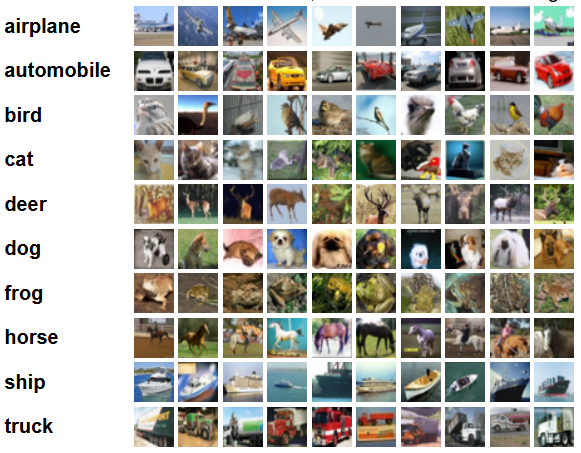

In [34]:
# Your code to import matplotlib, pandas and numpy libraries
#
!pip install tensorflow
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# ...
# ...


##### Following code loads the CIFAR 10 datset.

___________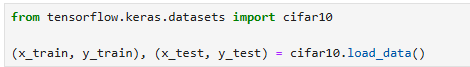

In [52]:
from tensorflow.keras.datasets import cifar10
(x_train,y_train),(x_test,y_test)=cifar10.load_data()

In [53]:
# Your code to print shapes of training and test data. Check how the data looks
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)
# ...
# ...


(50000, 32, 32, 3)
(10000, 32, 32, 3)
(50000, 1)
(10000, 1)


In [54]:
# Your code to print the shape of one image
x_train[9].shape
# ...


(32, 32, 3)

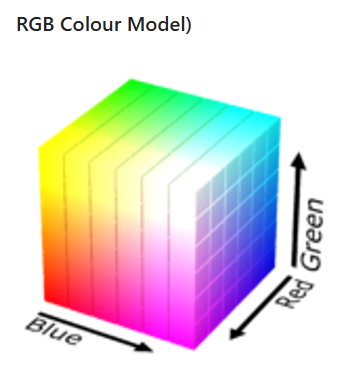

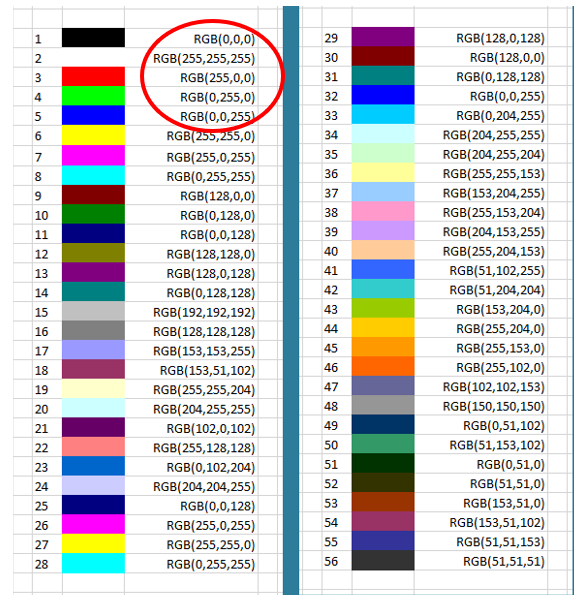

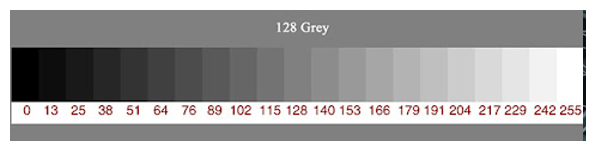

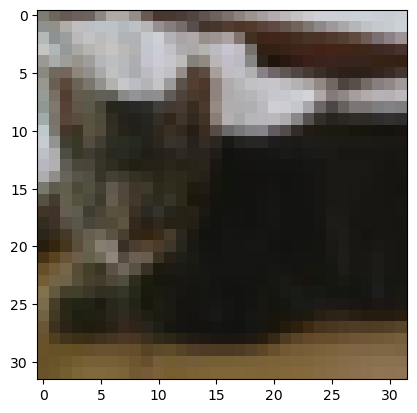

In [55]:
# Your code to show any sample image in the dataset. Use - plt.imshow()
plt.imshow(x_train[9])
# ...


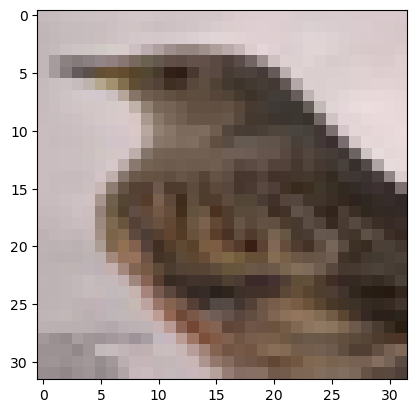

In [56]:
# Show any other image
plt.imshow(x_train[18])
# ...


____________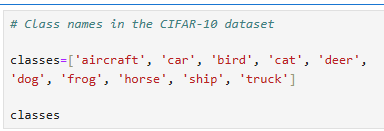

In [57]:
classes=["aircraft","car","bird", "cat","deer","dog","frog","horse","ship","truck"]
classes

['aircraft',
 'car',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

______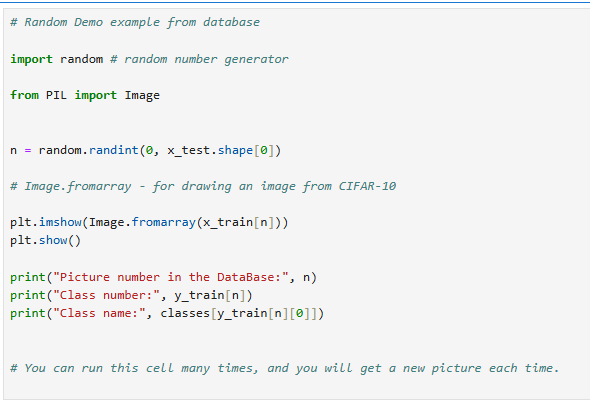

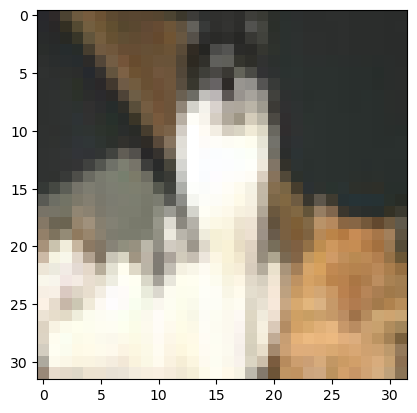

Picture number in the DataBase: 4072
Class number: [3]
Class name: cat


In [58]:
import random
from PIL import Image
n=random.randint(0,x_test.shape[0])
plt.imshow(Image.fromarray(x_train[n]))
plt.show()
print("Picture number in the DataBase:",n)
print("Class number:",y_train[n])
print("Class name:",classes[y_train[n][0]])

## PreProcessing

In [59]:
# Your code to print one image in digitals. Check what pixels look like. 
print(x_train[4])
# ...


[[[170 180 198]
  [168 178 196]
  [177 185 203]
  ...
  [162 179 215]
  [158 178 214]
  [157 177 212]]

 [[168 181 198]
  [172 185 201]
  [171 183 200]
  ...
  [159 177 212]
  [156 176 211]
  [154 174 209]]

 [[154 170 186]
  [149 165 181]
  [129 144 162]
  ...
  [161 178 214]
  [157 177 212]
  [154 174 209]]

 ...

 [[ 74  84  80]
  [ 76  85  81]
  [ 78  85  82]
  ...
  [ 71  75  78]
  [ 68  72  75]
  [ 61  65  68]]

 [[ 68  76  77]
  [ 69  77  78]
  [ 72  79  78]
  ...
  [ 76  80  83]
  [ 71  75  78]
  [ 71  75  78]]

 [[ 67  75  78]
  [ 68  76  79]
  [ 69  75  76]
  ...
  [ 75  79  82]
  [ 71  75  78]
  [ 73  77  80]]]


In [60]:
# Your code to print the shape of any image i.e particular value in the x_train
print(x_train[4].shape)
# ...


(32, 32, 3)


In [61]:
# Your code to print the maximum value in x_train. Hint - Use .max()
print(x_train.max())
# ...


255


____________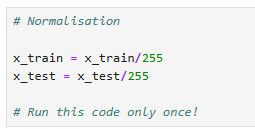

In [62]:
x_train=x_train/255
x_test=x_test/255

__________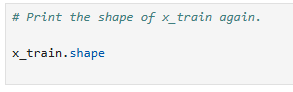

In [63]:
x_train.shape

(50000, 32, 32, 3)

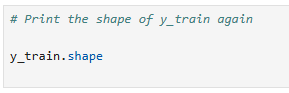

In [64]:
y_train.shape

(50000, 1)

## One hot vector encoding.
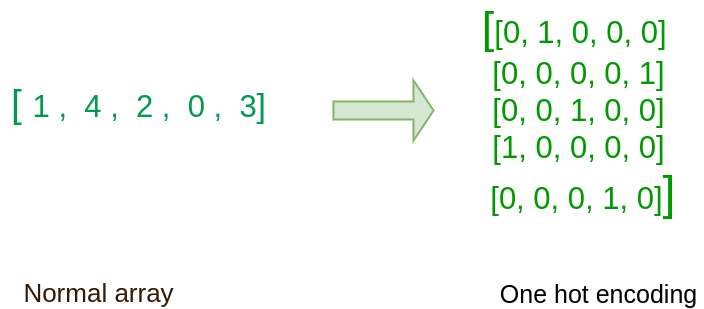


The "to_categorical()" is converting the integer value to binary categorical matrix : https://keras.io/api/utils/python_utils/#to_categorical-functionLinks to an external site.

________________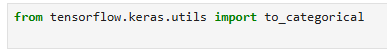

In [65]:
from tensorflow.keras.utils import to_categorical

___________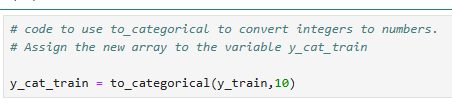

In [66]:
y_cat_train=to_categorical(y_train,10)

In [67]:
# Your code to print the shape of the array y_cat_train
print(y_cat_train.shape)
# ...


(50000, 10)


In [68]:
# Your code to print any single value in the array y_cat_train and print y_train with the same index.

# Compare the result for better understanding of "to_categorical()"
print(y_cat_train[4])
print(y_train[4])

# ...
# ...


[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
[1]


In [69]:
# Your code to:
# Convert y_test to the encoded vector in the same manner
# Assign it to the variable y_cat_test
y_cat_test=to_categorical(y_test,10)
#  y_cat_test = ...


____________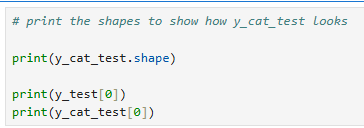

In [70]:
print(y_cat_test.shape)
print(y_test[0])
print(y_cat_test[0])

(10000, 10)
[3]
[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]


-----------------

## Creating a CNN Model

_____________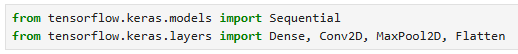

In [71]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Conv2D, MaxPool2D,Flatten

#### Please read the following links before creating code for the next cell

https://keras.io/api/layers/convolution_layers/convolution2d/
    
https://keras.io/api/layers/pooling_layers/max_pooling2d/

In [72]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential()

# Block 1
model.add(Conv2D(32, (3,3), padding="same", activation="relu", input_shape=(32,32,3)))
model.add(BatchNormalization())
model.add(Conv2D(32, (3,3), padding="same", activation="relu"))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

# Block 2
model.add(Conv2D(64, (3,3), padding="same", activation="relu"))
model.add(BatchNormalization())
model.add(Conv2D(64, (3,3), padding="same", activation="relu"))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

# Block 3
model.add(Conv2D(128, (3,3), padding="same", activation="relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.3))

model.add(Flatten())

# Dense layers (better than single 250)
model.add(Dense(256, activation="relu"))
model.add(Dropout(0.4))
model.add(Dense(128, activation="relu"))

# Output
model.add(Dense(10, activation="softmax"))



/opt/anaconda3/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


__________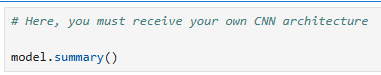

In [73]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 699,050 (2.67 MB)

 Trainable params: 698,602 (2.66 MB)

 Non-trainable params: 448 (1.75 KB)

### We could use early stopping in Keras to break from the training.
### What this does is for successive iterations it monitors the loss. If the loss does not decreases for a certain number of iterations denoted by variable 'patience' then the training stops.
### Following code shows how you can use early stopping.


___________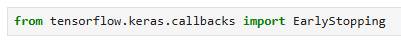

In [74]:
from tensorflow.keras.callbacks import EarlyStopping

__________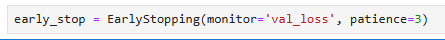

In [75]:
early_stop=EarlyStopping(monitor="val_loss",patience=3)

In [77]:
# Compile the model
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    x_train,
    y_cat_train,
    epochs=12,
    validation_data=(x_test, y_cat_test)
)

# Evaluate the model
test_loss, test_accuracy = model.evaluate(x_test, y_cat_test)

# Print final accuracy
print("Final Test Accuracy:", test_accuracy)


Epoch 1/12


2026-02-25 21:41:58.023644: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 46s 28ms/step - accuracy: 0.3885 - loss: 1.6736 - val_accuracy: 0.5095 - val_loss: 1.3603
Epoch 2/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - accuracy: 0.5658 - loss: 1.2226 - val_accuracy: 0.6415 - val_loss: 1.0419
Epoch 3/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - accuracy: 0.6417 - loss: 1.0193 - val_accuracy: 0.5408 - val_loss: 1.2752
Epoch 4/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - accuracy: 0.6855 - loss: 0.9055 - val_accuracy: 0.7082 - val_loss: 0.8498
Epoch 5/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - accuracy: 0.7131 - loss: 0.8263 - val_accuracy: 0.7345 - val_loss: 0.7715
Epoch 6/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 45s 29ms/step - accuracy: 0.7339 - loss: 0.7758 - val_accuracy: 0.7536 - val_loss: 0.7191
Epoch 7/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 45s 29ms/step - accuracy: 0.7511 - loss: 0.7187 - val_accuracy: 0.7726 - val_loss: 0.6678
Epoch 8/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - accuracy: 0.7644 - loss: 0.68

________________________________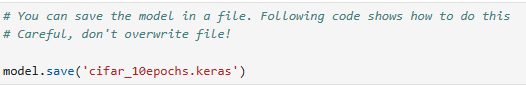

In [27]:
model.save("cifar_10epochs.keras")

In [28]:
YOUR_LAST_SID_DIGITAL= 2
# Your code to fit the model (model.fit). 

# Use additional parameter -  callbacks = [early_stop] to enable early stopping. 
# Use 'history' array to save the training parameters for each epoch

# history = ....


______________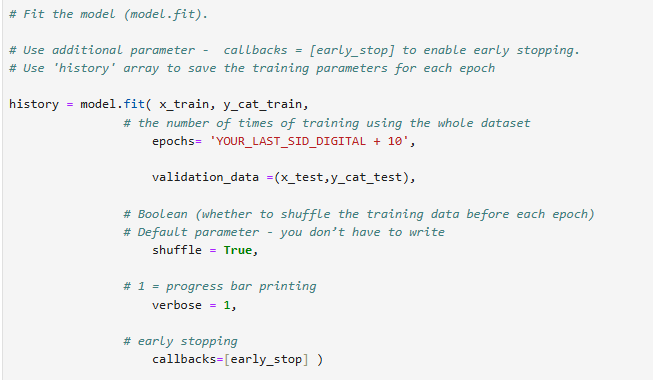

In [ ]:
history=model.fit(x_train,y_cat_train,
                 epochs=YOUR_LAST_SID_DIGITAL+10,
                 validation_data=(x_test,y_cat_test),
                 shuffle=True,
                 verbose=1,
                 callbacks=[early_stop])

Epoch 1/12


2026-02-25 21:07:28.094177: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2026-02-25 21:07:28.097772: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 47s 29ms/step - accuracy: 0.4119 - loss: 1.6304 - val_accuracy: 0.5240 - val_loss: 1.3083
Epoch 2/12
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - accuracy: 0.5823 - loss: 1.1830 - val_accuracy: 0.6344 - val_loss: 1.0474
Epoch 3/12
 673/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step - accuracy: 0.6416 - loss: 1.0317

##### You can save the model in a file. Following code shows how to do this.

________________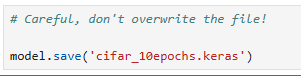

In [ ]:
model.save("cifar_10epochs.keras")

##### Yiu can save the loss at every step. Following code shows how to do this. 

___________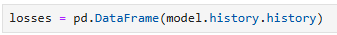

In [ ]:
losses=pd.DataFrame(model.history.history)

In [ ]:
# You code to print the first few rows of losses.
print(losses.head())
# ...


#### Visualise a plot between accuracy vs val_accuracy for all steps.

#### x axis will have the steps (epochs) 
#### y axis will have accuracy and val_accuracy 


_________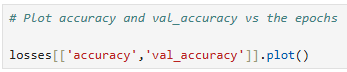

In [ ]:
losses[["accuracy","val_accuracy"]].plot()

<html> <h4 style="font-style:italic; color:blue;"> Just run the next 3 cells using 'Ctrl' + 'Enter' </h4> </html>

In [ ]:
# Plot accuracy and val_accuracy for the neural network training process in more detail

history_dict = history.history

acc_values = history_dict['accuracy']
val_acc_values = history_dict['val_accuracy']
epochs = range(1, len(acc_values) + 1)

plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, acc_values, 'bo', label='Training acc')
plt.plot(epochs, val_acc_values, 'b', label='Validation acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

__________________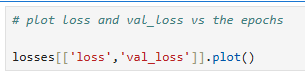

In [ ]:
losses[["loss","val_loss"]].plot()

_____________________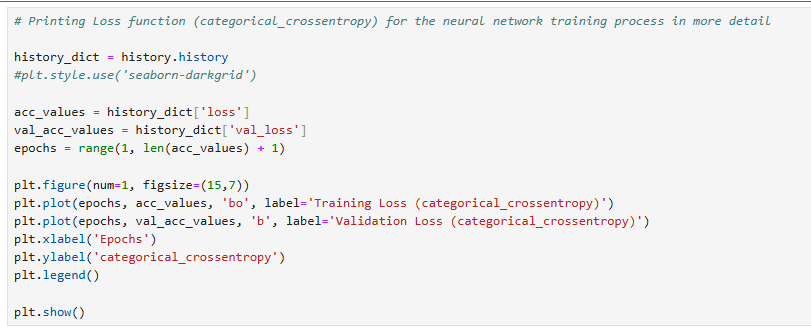

In [ ]:
history_dict=history.history

acc_values=history_dict["loss"]
val_acc_values=history_dict["val_loss"]
epochs=range(1,len(acc_values)+1)

plt.figure(num=1, figsize=(15,7))
plt.plot(epochs,acc_values,"bo",label="Training Loss (categorical_crossentropy)")
plt.plot(epochs,val_acc_values,"b",label="Validation Loss (categorical_crossentropy)")
plt.xlabel("Epochs")
plt.ylabel("categorical_crossentropy")
plt.legend()
plt.show()

__________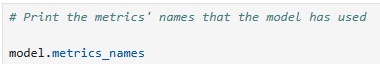

In [ ]:
model.metrics_names

___________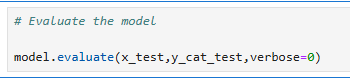

In [ ]:
model.evaluate(x_test,y_cat_test,verbose=0)

In [ ]:
# Evaluate the model

model.evaluate(x_test,y_cat_test,verbose=0)

___________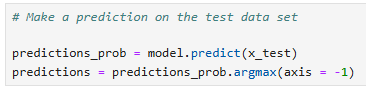

In [ ]:
predictions_prob=model.predict(x_test)
predictions=predictions_prob.argmax(axis=-1)

_______________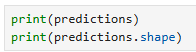

In [ ]:
print(predictions)
print(predictions.shape)

##### You could get the full classification report. 

_____________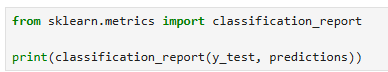

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test,predictions))

##### You could also get and plot confusion matrix.

https://github.com/matplotlib/matplotlib/issues/14751

______________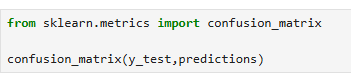

In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,predictions)

_______________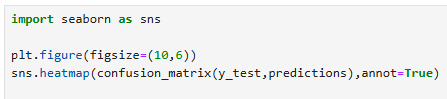

In [ ]:
import seaborn as sns
plt.figure(figsize=(10,6))
sns.heatmap(confusion_matrix(y_test,predictions),annot=True)

### Following code makes a prediction on specific image.

____________________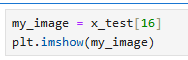

In [ ]:
my_image=x_test[4]
plt.imshow(my_image)

______________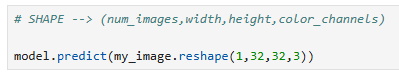

In [ ]:
model.predict(my_image.reshape(1,32,32,3))

In [ ]:
# Find the highest probability value in the vector above. 
# What output value does it point to?

_______________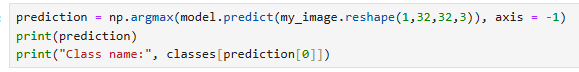

In [ ]:
prediction=np.argmax(model.predict(my_image.reshape(1,32,32,3)),axis=-1)
print(prediction)
print("Class name",classes[prediction[0]])

### Let's use a trained neural network
You can run the following code many times

Note the recognition probabilities for each image

<html> <h4 style="font-style:italic; color:blue;"> Just run the next 3 cells using 'Ctrl' + 'Enter' </h4> </html>

In [ ]:
from tensorflow.keras.preprocessing.image import array_to_img

# Class names in the CIFAR-10 dataset
classes=['aircraft', 'car', 'bird', 'cat', 'deer',
'dog', 'frog', 'horse', 'ship', 'truck']

# we take a random element 'random.randint()' from the test sample
# and observe: the neural network will guess or not
index = random.randint(0, x_test.shape[0])
plt.imshow(array_to_img(x_test[index]))

# test image conversion
x = x_test[index]
x = np.expand_dims(x, axis=0)

# start recognition
prediction = model.predict(x)
sample = x

# converting the result from one hot encoding format
ans = np.argmax(prediction)

fig = plt.figure(figsize=(12,4))

ax = fig.add_subplot(1, 2, 2)
bar_list = ax.bar(np.arange(10), prediction[0], align='center')
bar_list[ans].set_color('g')
ax.set_xticks(np.arange(10))
ax.set_xlim([-1, 10])
ax.grid('on')

plt.show()

print('The predicted answer: {}'.format((classes[ans])), "\n",
     'Correct answer: {}'.format(classes[y_test[index][0]]) )

print(classes)


# You can run this cell many times, and each time you will get a new picture,
# which this neural network will recognise with the probability indicated on the graph.

<html> <h2 style="font-style:bold; color:red;"> Lab Logbook requirements </h2> </html>

### 1. Plot of the model building code and model's summary

### 2. Please ensure to document in your laboratory logbook a graphical representation depicting the train loss and validation loss trends (4 graphs).

### 3. Based on this analysis, determine the optimal number of epochs for training your model. 

In [ ]:
Prediction:[6]
Class Name: Frog
Highest Value:8.1434292e-01

<html> <h2 style="font-style:italic; color:blue;"> Task 2 (Optional): </h2> </html>

#### Evaluate your model for different optimisers available in the Keras. 

https://keras.io/api/optimizers/

- Store the optimisers in an array.
- Use for loop to fit, compile, and  test your model.
- Plot the accuracy vs optimiser


In [ ]:
# Create a list containing the names of optimisers (Don't use 'AdamW' and 'Adafactor')
# Create an empty list to store scores

# For every optimiser
   # compile your model
   # fit your model, use epochs=3 for each optimiser (otherwise the training will take a long time)
   # using model.evaluate() find score and append the score in a list

# Plot score vs optimiser 